# Candlesticks — styler settings

Companion to `candlesticks-params.ipynb` (user kwargs): this notebook tests the *settings path* — `Candlesticks` with no color kwargs resolving its palette from `candle.*` settings through `resolve_color`. Styles are passed as a prebuilt `Styler` via `Chart(style=...)`, using canonical dotted keys (`<role>[.<variant>].<facet>`). Taxonomy in `notes/candlestick-styles.md`.

In [1]:
from mplchart.chart import Chart
from mplchart.primitives import Candlesticks
from mplchart.samples import sample_prices
from mplchart.styles import Styler, get_styler

prices = sample_prices().tail(60)
prices.tail()

,open,high,low,close,volume
date,,,,,
2025-11-11,269.809998,275.910004,269.799988,275.250000,46208300
2025-11-12,275.000000,275.730011,271.700012,273.470001,48398000
2025-11-13,274.109985,276.700012,272.089996,272.950012,49602800
2025-11-14,271.049988,275.959991,269.600006,272.410004,47399300
2025-11-17,268.815002,270.489990,265.730011,267.459991,42862157


In [2]:
def show_styled(prices, title, settings=(), stylesheet=None, rcparams=(), style=None, **kwargs):
    """Plot Candlesticks under a style — a spec via style=, or Styler pieces."""
    if style is None:
        if stylesheet or rcparams:
            style = Styler(settings=settings, rcparams=rcparams, stylesheet=stylesheet)
        else:
            style = get_styler('mplchart', overrides=settings)
    chart = Chart(prices, figsize=(12, 4), title=title, style=style)
    chart.plot(Candlesticks(**kwargs))
    chart.show()

## Shipped styles

`Chart(style=<name>)` resolves shipped styles by name via `resolve_style` — one zero-import `STYLE` dict module per style under `styles/lib/` (the directory is the registry). `stockcharts` carries its mode flags in the style itself.

In [3]:
from mplchart.styles import available_styles

available_styles()

['mplchart', 'nightclouds', 'stockcharts', 'tradingview']

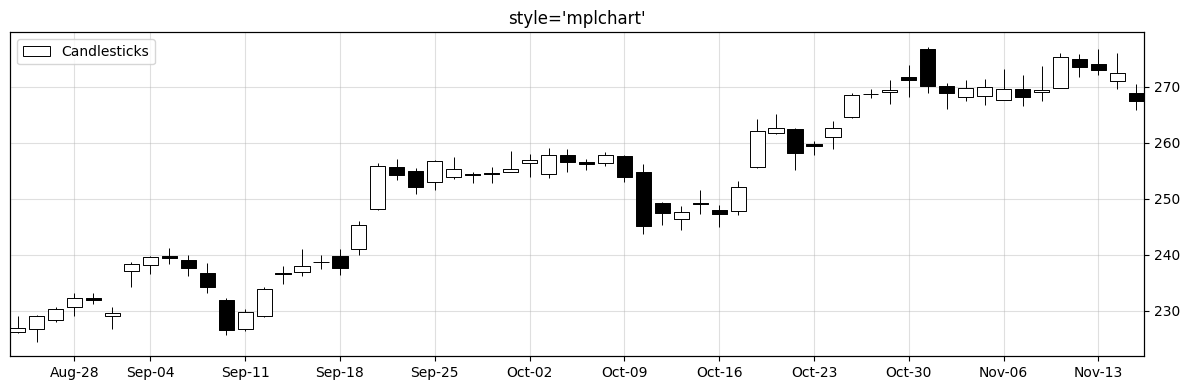

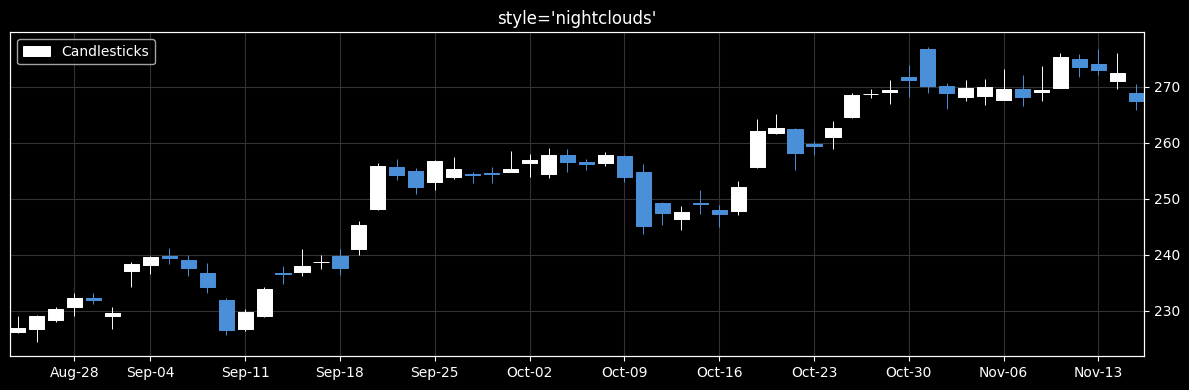

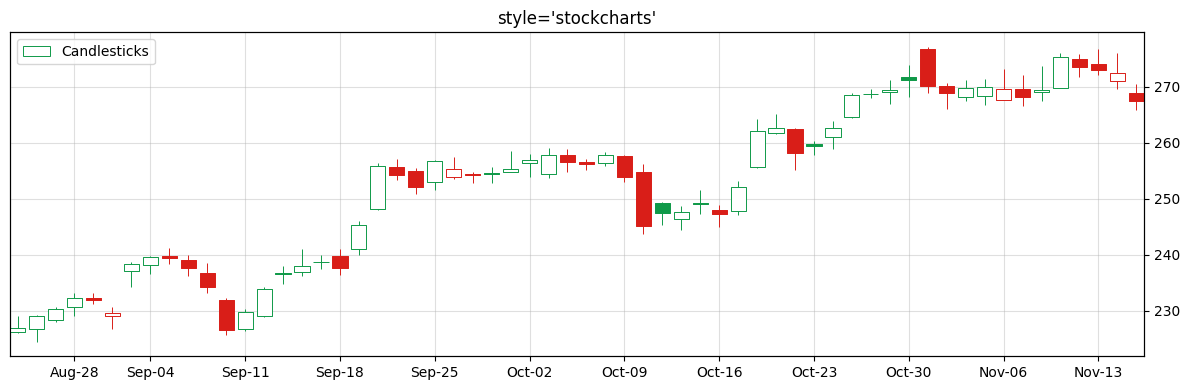

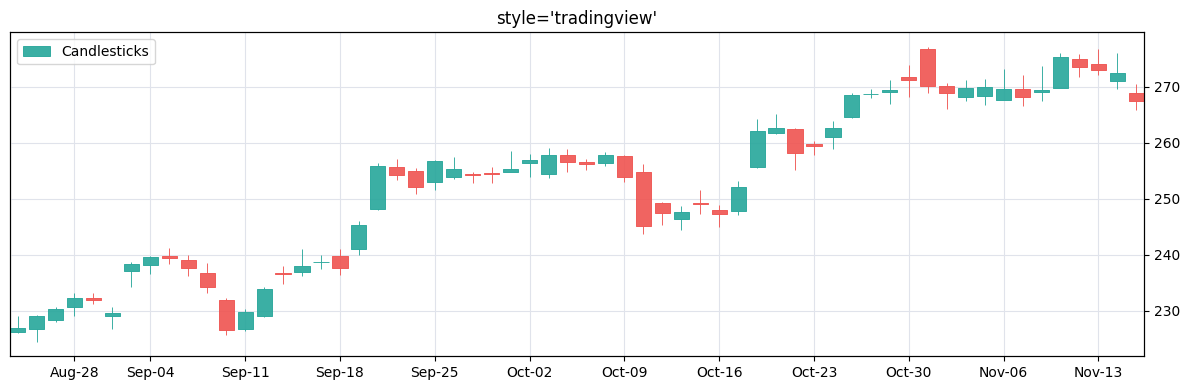

In [4]:
for name in available_styles():
    show_styled(prices, f"style={name!r}", style=name)

## Ad-hoc settings styles

Looks not shipped as builtins, passed as settings dicts — one per remaining scheme family:

- **yahoo** — filled bicolor + `wicks` neutral wicks
- **outlined** — pastel faces with dark `edge.up`/`edge.down` outlines (wicks follow the edges)
- **tinted** — no up/down keys → mono hollow family; `candle.off` tints the hollow bodies

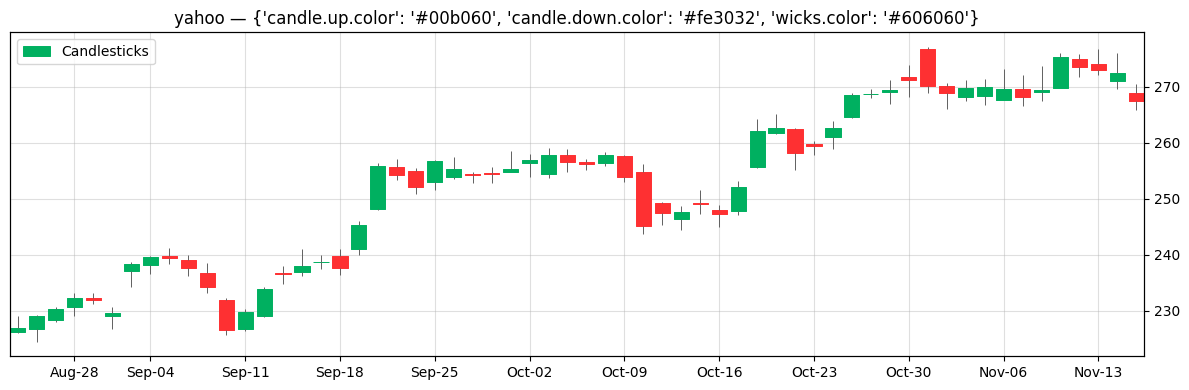

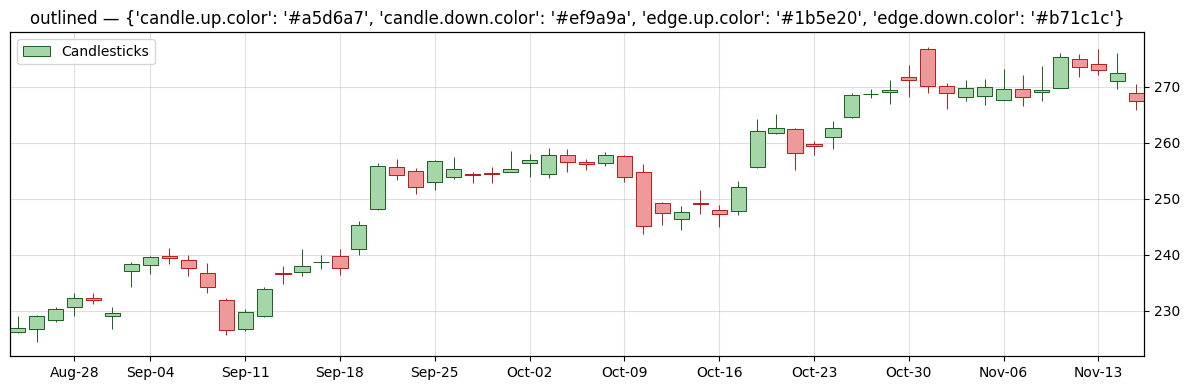

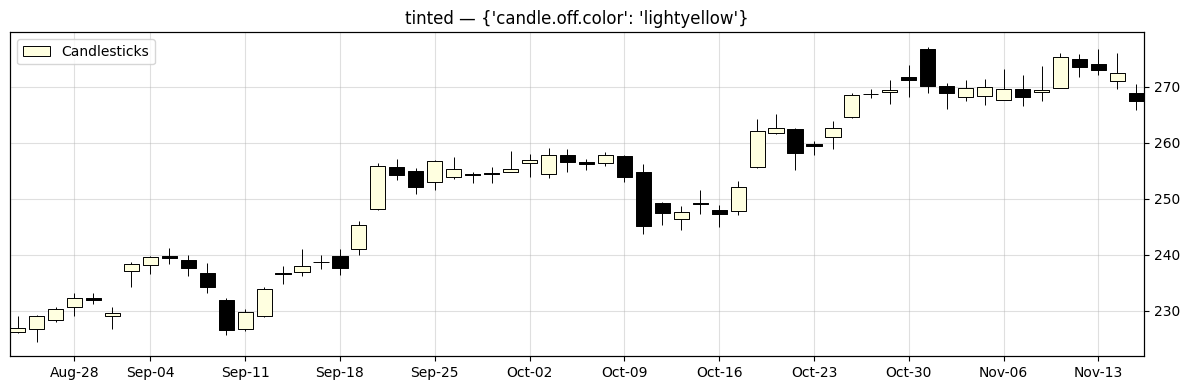

In [5]:
STYLES = {
    "yahoo": {
        "candle.up.color": "#00b060",
        "candle.down.color": "#fe3032",
        "wicks.color": "#606060",
    },
    "outlined": {
        "candle.up.color": "#a5d6a7",
        "candle.down.color": "#ef9a9a",
        "edge.up.color": "#1b5e20",
        "edge.down.color": "#b71c1c",
    },
    "tinted": {
        "candle.off.color": "lightyellow",
    },
}

for name, settings in STYLES.items():
    show_styled(prices, f"{name} — {settings}", settings)

## Stylesheet-backed styles

The Styler loads the rc half itself: `stylesheet=` takes a stock matplotlib style name (or an `.mplstyle` path), collapses it eagerly under any explicit `rcparams`, and the canvas applies it through the scoped rc context — no `plt.style.use`, no manual `rc_context`, no ambient state. Settings ride alongside for the candle palette: a full dark style is a one-liner.

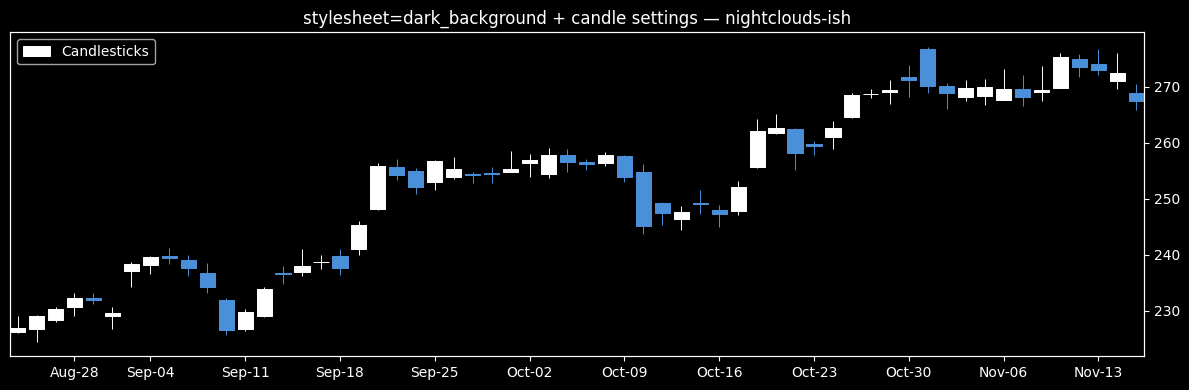

In [6]:
show_styled(prices, "stylesheet=dark_background + candle settings — nightclouds-ish",
            settings={"candle.up.color": "white", "candle.down.color": "#4a90d9"},
            stylesheet="dark_background")

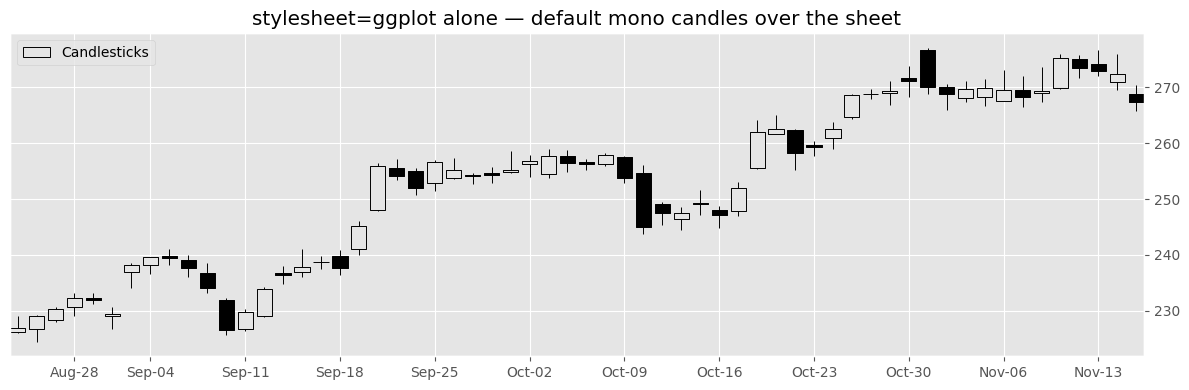

In [7]:
show_styled(prices, "stylesheet=ggplot alone — default mono candles over the sheet",
            stylesheet="ggplot")

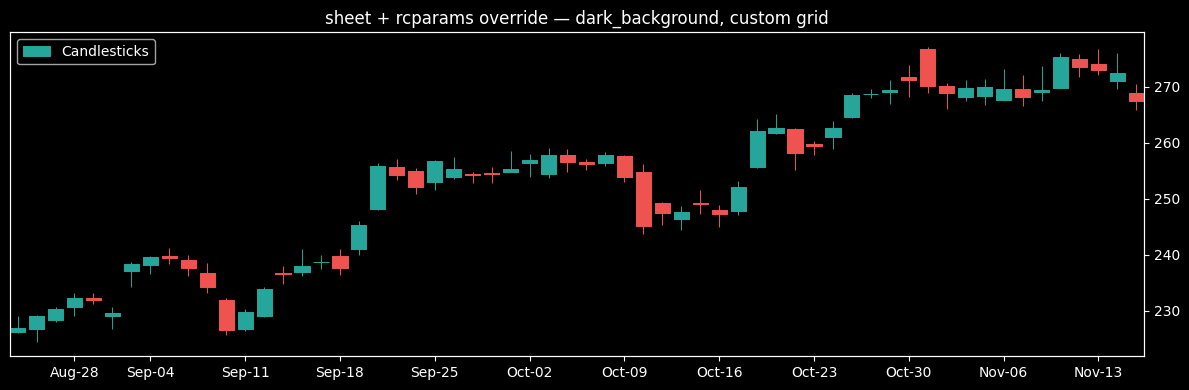

In [8]:
show_styled(prices, "sheet + rcparams override — dark_background, custom grid",
            settings={"candle.up.color": "#26a69a", "candle.down.color": "#ef5350"},
            stylesheet="dark_background", rcparams={"grid.color": "#333333"})

## Mode kwargs over a style palette

`hollow` and `use_prev_close` are mode flags, not palette — they compose with the style's colors instead of bypassing them. The settings family defaults to filled (up/dn present); `hollow=True` flips it to colored hollow, and adding `use_prev_close=True` reaches the StockCharts cell. The same flags exist as settings (`candle.hollow`/`candle.use_prev_close` — the shipped stockcharts style); the chain is kwarg → setting → family default.

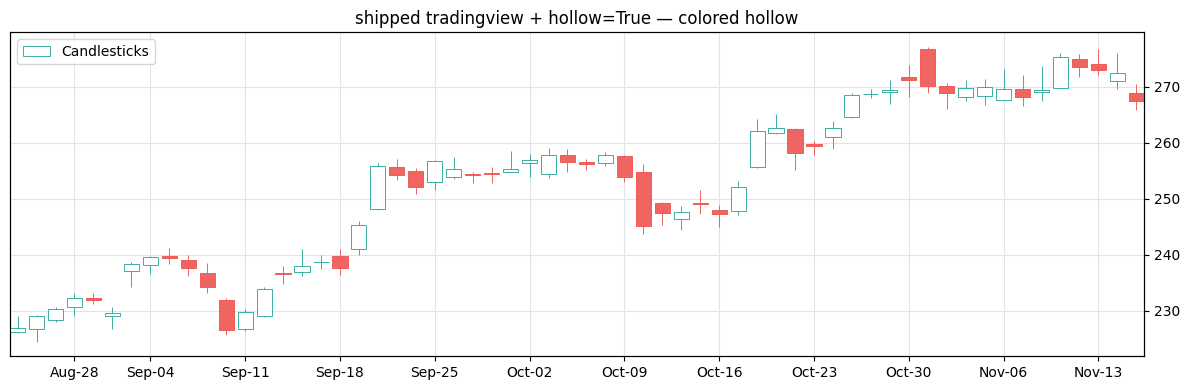

In [9]:
show_styled(prices, "shipped tradingview + hollow=True — colored hollow",
            style="tradingview", hollow=True)

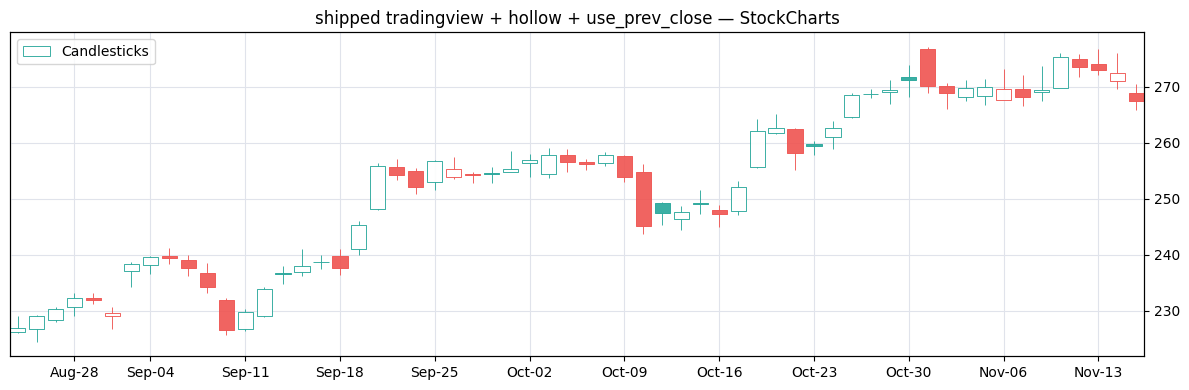

In [10]:
show_styled(prices, "shipped tradingview + hollow + use_prev_close — StockCharts",
            style="tradingview", hollow=True, use_prev_close=True)

## Color kwargs bypass the style

Schemes are atomic: any color kwarg declares a complete palette and ignores the settings — the missing side falls to `text.color`, not to the style.

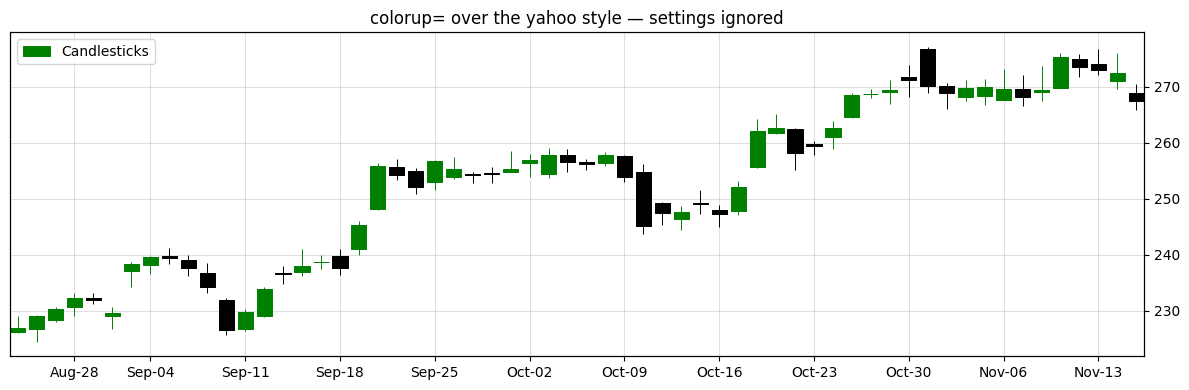

In [11]:
show_styled(prices, "colorup= over the yahoo style — settings ignored",
            STYLES["yahoo"], colorup="green")

## mplfinance emulation

Translate every shipped mplfinance style into mplchart terms: `marketcolors` → candle settings (the compat stretch goal from `styler-sketch.md`), the rc-ish keys → the Styler's rc half (`stylesheet=` base + `rcparams=` overrides), applied by the canvas through the styler's scoped rc context. Gaps show up as visual differences.

In [12]:
import matplotlib as mpl
import mplfinance as mpf

from mplchart.colors import normalize_color


def same_color(a, b):
    """Spelling-insensitive color equality ("k" == "black"); None == None."""
    if a is None or b is None:
        return a is b
    return normalize_color(a) == normalize_color(b)


def mpf_style_rc(style):
    """rc overrides of an mplfinance style dict: raw rc ⊕ named color keys
    (the base_mpl_style rides separately as Styler(stylesheet=))."""
    rc = dict(style.get("rc") or {})
    named = {
        "facecolor": "axes.facecolor",
        "figcolor": "figure.facecolor",
        "gridcolor": "grid.color",
        "gridstyle": "grid.linestyle",
        "edgecolor": "axes.edgecolor",
    }
    for src, dst in named.items():
        if style.get(src) is not None:
            rc[dst] = style[src]
    # mplfinance's explicit_grid rule: any grid field present → grid on, alpha 1.0
    if any(style.get(k) is not None for k in ("gridcolor", "gridstyle", "gridaxis")):
        rc.setdefault("axes.grid", True)
        rc.setdefault("grid.alpha", 1.0)
    if gax := style.get("gridaxis"):
        if "horizontal".startswith(gax):
            rc["axes.grid.axis"] = "y"
        elif "vertical".startswith(gax):
            rc["axes.grid.axis"] = "x"
    return rc


def mpf_candle_settings(marketcolors):
    """marketcolors → mplchart candle settings ('i' = inherit → omit the key)."""
    def side(entry, key):
        value = entry.get(key) if isinstance(entry, dict) else entry
        return None if value in (None, "i", "inherit") else value

    settings = {}
    for key, role in [("up", "candle.up.color"), ("down", "candle.down.color")]:
        if value := side(marketcolors.get("candle"), key):
            settings[role] = value
    for key, role in [("up", "edge.up.color"), ("down", "edge.down.color")]:
        if value := side(marketcolors.get("edge"), key):
            settings[role] = value
    wickup = side(marketcolors.get("wick"), "up")
    wickdn = side(marketcolors.get("wick"), "down")
    edgeup = settings.get("edge.up.color", settings.get("candle.up.color"))
    edgedn = settings.get("edge.down.color", settings.get("candle.down.color"))
    if same_color(wickup, wickdn):
        if wickup is not None:
            settings["wicks.color"] = wickup  # neutral wicks (yahoo-style)
    elif same_color(wickup, edgeup) and same_color(wickdn, edgedn):
        pass  # wicks follow the edges — our default, no key needed
    else:
        print(f"per-direction wicks not representable: {wickup!r} vs {wickdn!r}")
    if hollow := marketcolors.get("hollow"):
        settings["candle.off.color"] = hollow
    if (alpha := marketcolors.get("alpha")) not in (None, 1.0):
        settings["candle.alpha"] = alpha
    return settings

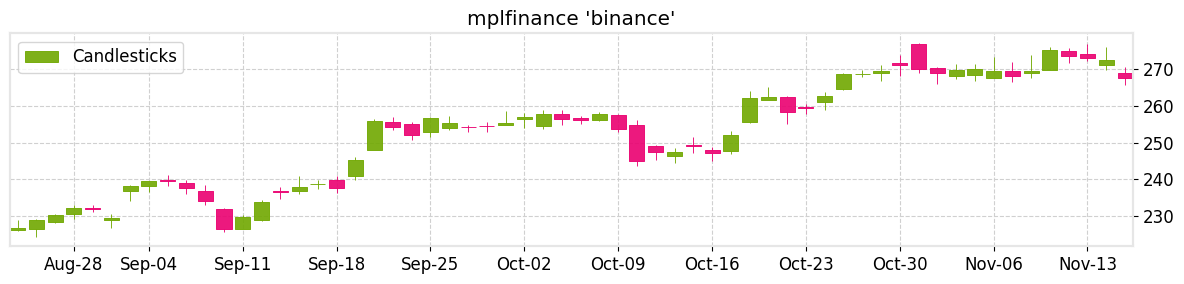

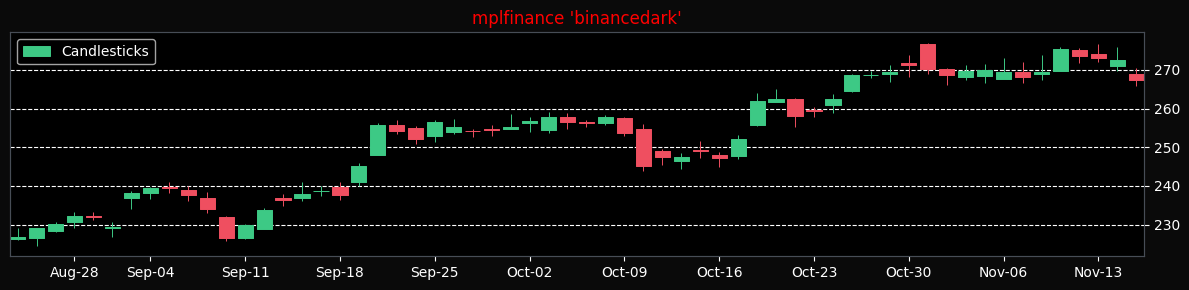

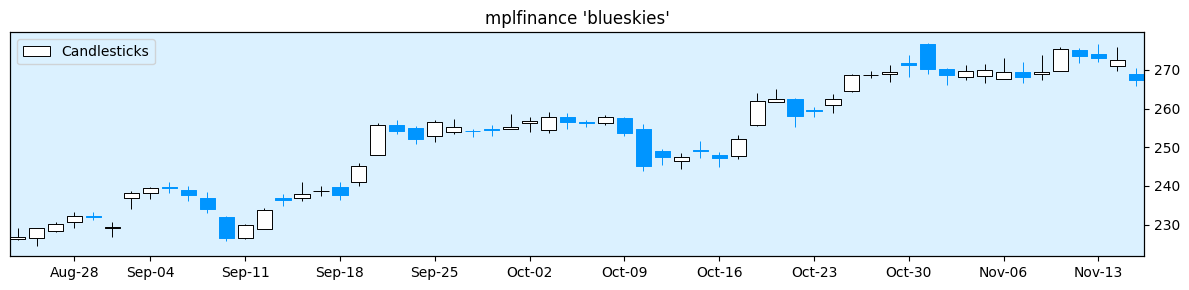

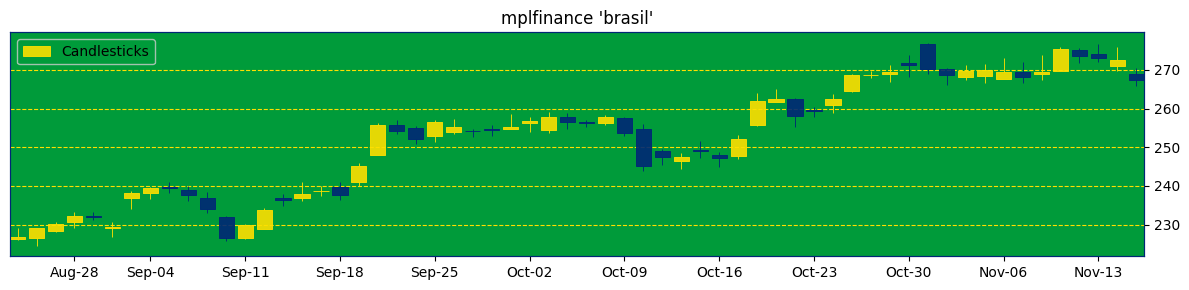

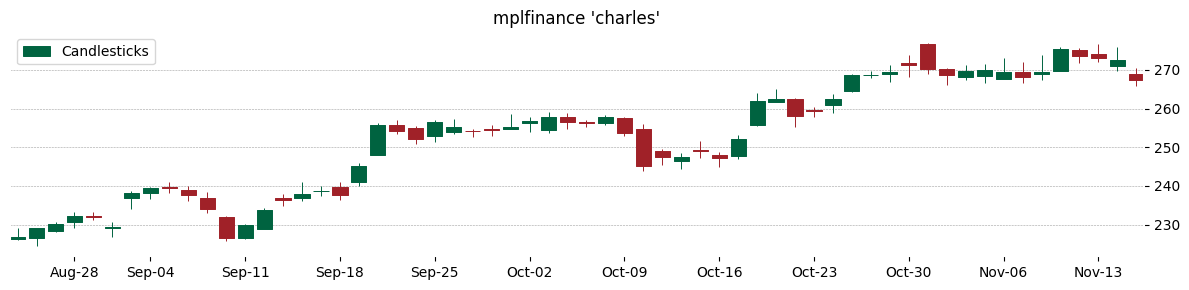

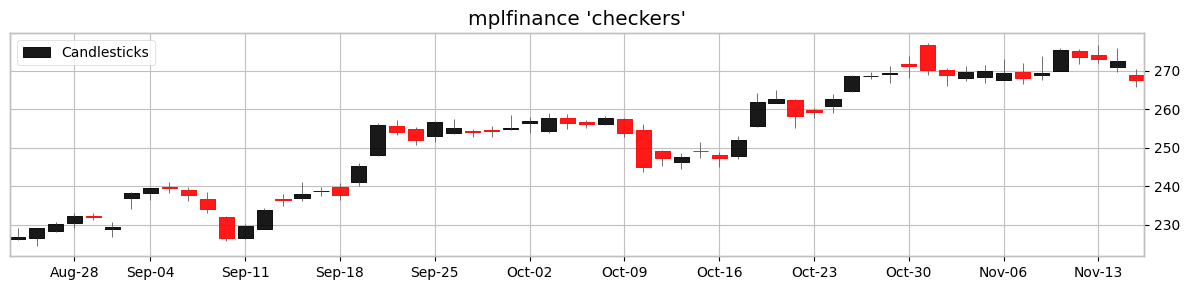

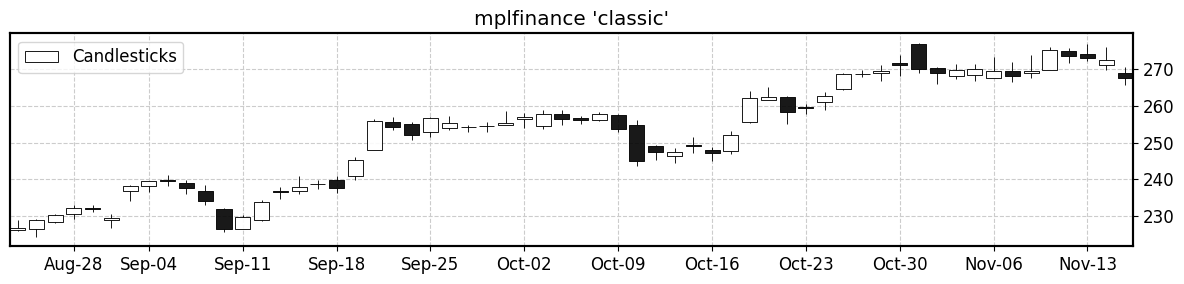

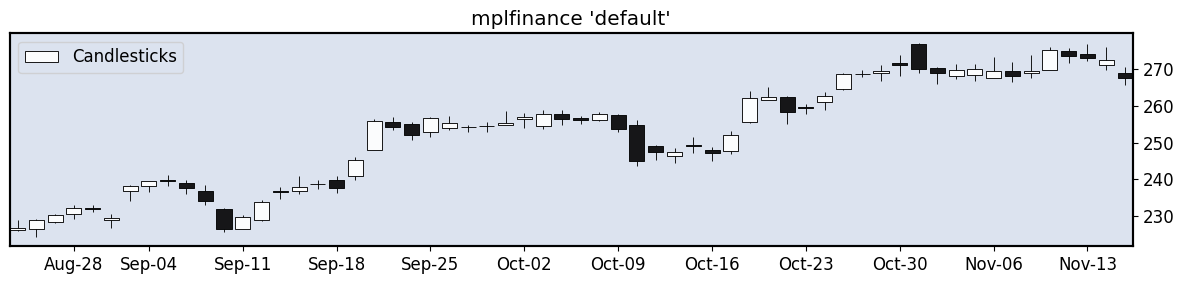

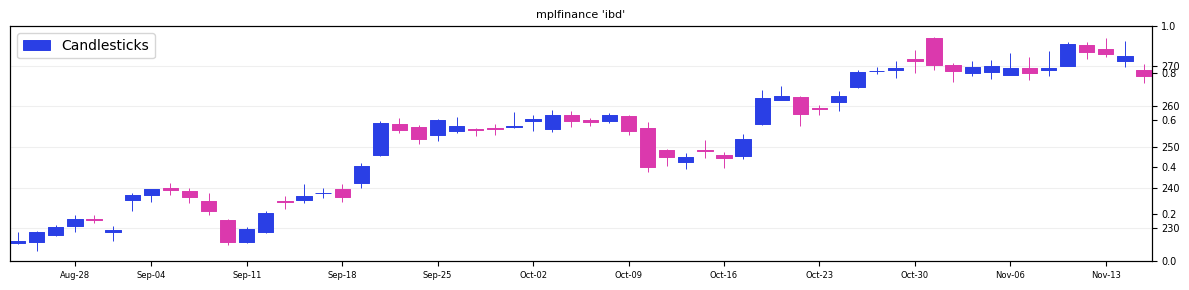

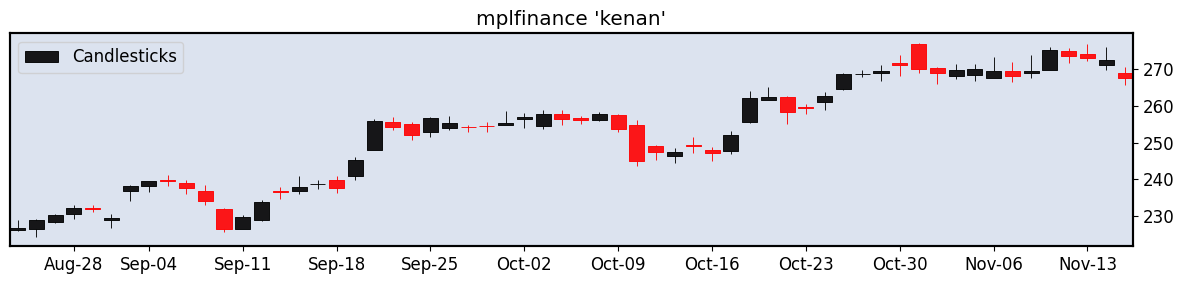

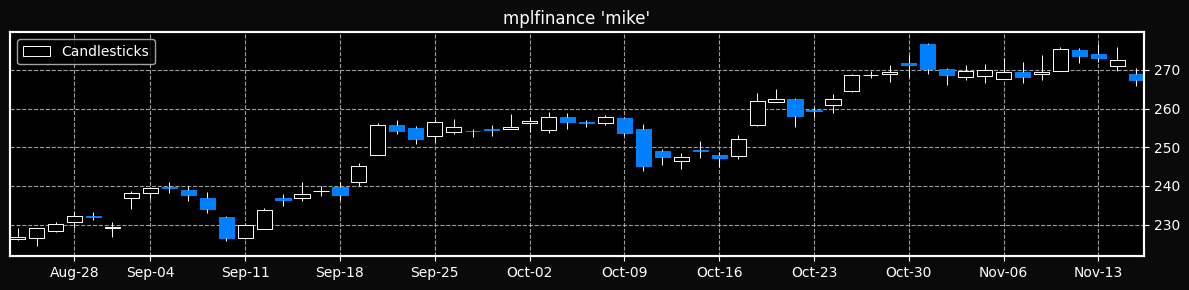

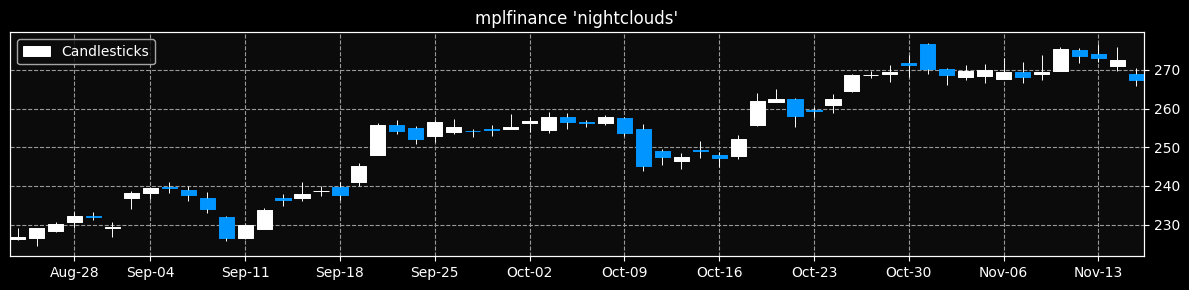

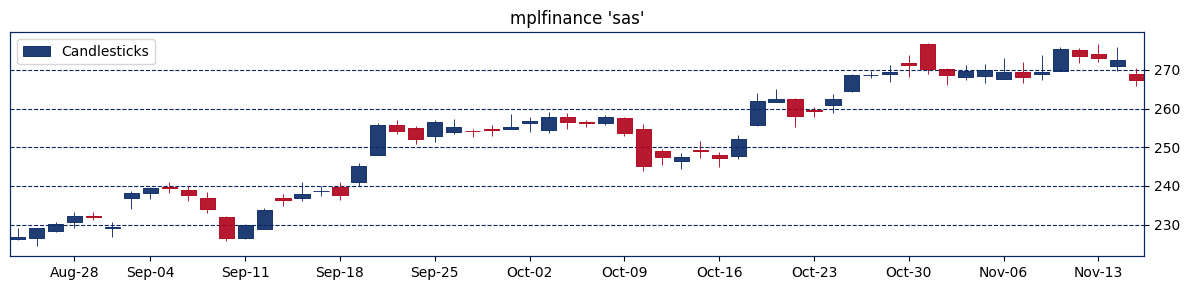

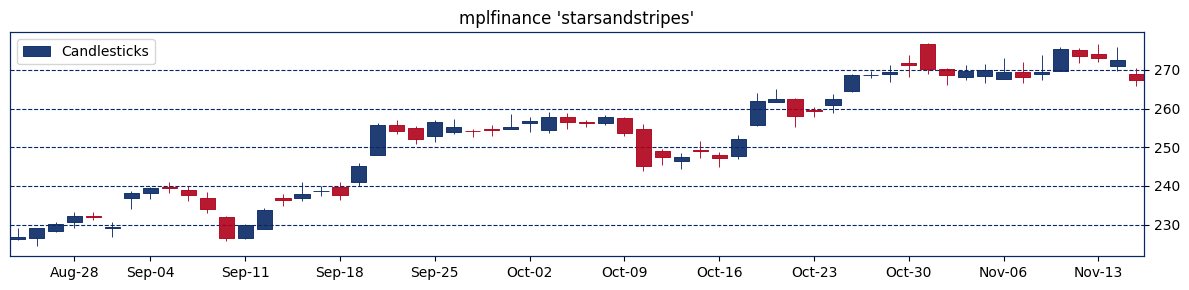

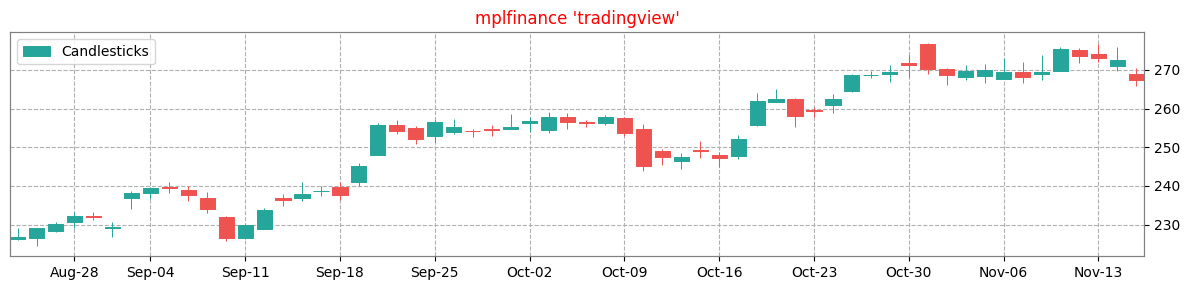

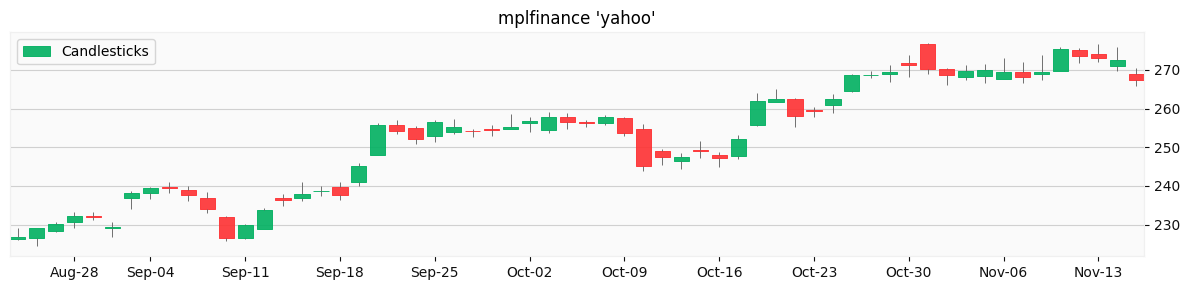

In [13]:
def show_mpf_emulation(prices, name):
    """Render one mplfinance style: base sheet + rc overrides + candle settings."""
    style = mpf.make_mpf_style(base_mpf_style=name)
    base = style.get("base_mpl_style")
    styler = Styler(
        settings=mpf_candle_settings(style["marketcolors"]),
        rcparams=mpf_style_rc(style),
        stylesheet=base if base in mpl.style.library else None,
    )
    chart = Chart(prices, figsize=(12, 3), title=f"mplfinance '{name}'", style=styler)
    chart.plot(Candlesticks())
    chart.show()


for name in mpf.available_styles():
    show_mpf_emulation(prices, name)

### Coverage notes

- `marketcolors` map 1:1 onto the candle settings — no style needed a key we don't have (the per-direction wick check above stays silent).
- The rc half (backgrounds, grids, text) rides in the Styler — `stylesheet=` (base sheet, collapsed eagerly) plus `rcparams=` overrides — and applies through the wired rc context at the canvas choke points; no ambient rc mutation.
- Volume and mav colors have vocabulary (`volume.*`, list-valued `sma.color`) but await the Volume retrofit.
- `y_on_right`, `vcedge`, `vcdopcod`: declined — layout/behavior, not styling.